In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# CNN

In [ ]:
import os
import copy
import math
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18

DATA_DIR = "/content/drive/MyDrive/fmri_project/outputs/" # Corrected to the directory
SEED = 42
BATCH_SIZE = 8
LR = 3e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 80
PATIENCE = 12
NUM_WORKERS = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# Load the .npz archive once
fmri_data = np.load(os.path.join(DATA_DIR, "fmri_features.npz"))

ages = fmri_data["ages"]
full_vec = fmri_data["FULL"]
ll_vec = fmri_data["LL"]
lr_vec = fmri_data["LR"]
rr_vec = fmri_data["RR"]
subjects = fmri_data["subjects"]

print("ages:", ages.shape)
print("FULL:", full_vec.shape)
print("LL:", ll_vec.shape)
print("LR:", lr_vec.shape)
print("RR:", rr_vec.shape)
print("subjects:", subjects.shape)

assert len(ages) == len(full_vec) == len(ll_vec) == len(lr_vec) == len(rr_vec) == len(subjects)


Device: cpu
ages: (46,)
FULL: (46, 7140)
LL: (46, 1540)
LR: (46, 3136)
RR: (46, 1540)
subjects: (46,)


In [ ]:
def infer_n_from_upper_triangle_length(m):
    # solve n(n-1)/2 = m
    n = int((1 + np.sqrt(1 + 8 * m)) / 2)
    if n * (n - 1) // 2 != m:
        raise ValueError(f"Cannot infer square size from upper-triangle length {m}")
    return n

def vec_to_sym_matrix(batch_vec, n):
    # batch_vec: [N, n*(n-1)/2]
    N = batch_vec.shape[0]
    mat = np.zeros((N, n, n), dtype=np.float32)
    iu = np.triu_indices(n, k=1)
    mat[:, iu[0], iu[1]] = batch_vec
    mat[:, iu[1], iu[0]] = batch_vec
    return mat

def vec_to_rect_matrix(batch_vec, rows, cols):
    # batch_vec: [N, rows*cols]
    return batch_vec.reshape(-1, rows, cols).astype(np.float32)

def zero_diag(x):
    x = x.copy()
    idx = np.arange(x.shape[-1])
    x[:, idx, idx] = 0.0
    return x

def fisher_z(x, eps=1e-5):
    x = np.clip(x, -1 + eps, 1 - eps)
    return np.arctanh(x)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import copy
import math
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18

# -----------------------------
# Config
# -----------------------------
DATA_DIR = "/content/drive/MyDrive/fmri_project/outputs/"   # Corrected path
SEED = 42
BATCH_SIZE = 8
LR = 3e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 80
PATIENCE = 12
NUM_WORKERS = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# -----------------------------
# Load
# -----------------------------
# Load the .npz archive once
fmri_data = np.load(os.path.join(DATA_DIR, "fmri_features.npz"))

ages = fmri_data["ages"]
full_vec = fmri_data["FULL"]
ll_vec = fmri_data["LL"]
lr_vec = fmri_data["LR"]
rr_vec = fmri_data["RR"]
subjects = fmri_data["subjects"]

print("ages:", ages.shape)
print("FULL:", full_vec.shape)
print("LL:", ll_vec.shape)
print("LR:", lr_vec.shape)
print("RR:", rr_vec.shape)
print("subjects:", subjects.shape)

assert len(ages) == len(full_vec) == len(ll_vec) == len(lr_vec) == len(rr_vec) == len(subjects)

# -----------------------------
# Helpers
# -----------------------------
def infer_n_from_upper_triangle_length(m):
    n = int((1 + np.sqrt(1 + 8 * m)) / 2)
    if n * (n - 1) // 2 != m:
        raise ValueError(f"Cannot infer square size from upper-triangle length {m}")
    return n

def vec_to_sym_matrix(batch_vec, n):
    N = batch_vec.shape[0]
    mat = np.zeros((N, n, n), dtype=np.float32)
    iu = np.triu_indices(n, k=1)
    mat[:, iu[0], iu[1]] = batch_vec
    mat[:, iu[1], iu[0]] = batch_vec
    return mat

def fisher_z(x, eps=1e-5):
    x = np.clip(x, -1 + eps, 1 - eps)
    return np.arctanh(x)

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    r = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "r": r}

# -----------------------------
# Reconstruct FULL matrix
# -----------------------------
n_full = infer_n_from_upper_triangle_length(full_vec.shape[1])
print("FULL matrix size:", n_full)

full_mat = vec_to_sym_matrix(full_vec, n_full)
full_mat = fisher_z(full_mat)

# ResNet wants 3 channels; just repeat FULL 3 times
X_img = np.stack([full_mat, full_mat, full_mat], axis=1).astype(np.float32)  # [N, 3, 120, 120]

# -----------------------------
# Build compact hemisphere features
# -----------------------------
# These keep your novelty without forcing a wrong spatial atlas alignment.
hemi_feats = np.concatenate([
    ll_vec, lr_vec, rr_vec
], axis=1).astype(np.float32)

# train-time normalization will happen fold-wise

y = ages.astype(np.float32)

print("X_img:", X_img.shape)
print("hemi_feats:", hemi_feats.shape)
print("y:", y.shape)

# -----------------------------
# Dataset
# -----------------------------
class BrainAgeDataset(Dataset):
    def __init__(self, X_img, X_hemi, y):
        self.X_img = torch.tensor(X_img, dtype=torch.float32)
        self.X_hemi = torch.tensor(X_hemi, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_img[idx], self.X_hemi[idx], self.y[idx]

# -----------------------------
# Model
# -----------------------------
class ResNetWithHemi(nn.Module):
    def __init__(self, hemi_dim):
        super().__init__()
        self.cnn = resnet18(weights=None)
        self.cnn.fc = nn.Identity()

        self.hemi_mlp = nn.Sequential(
            nn.Linear(hemi_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU()
        )

        self.head = nn.Sequential(
            nn.Linear(512 + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x_img, x_hemi):
        img_feat = self.cnn(x_img)
        hemi_feat = self.hemi_mlp(x_hemi)
        x = torch.cat([img_feat, hemi_feat], dim=1)
        return self.head(x)

# -----------------------------
# Train / eval
# -----------------------------
def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()

    losses = []
    preds_all, y_all = [], []

    for xb_img, xb_hemi, yb in loader:
        xb_img = xb_img.to(device)
        xb_hemi = xb_hemi.to(device)
        yb = yb.to(device).unsqueeze(1)

        with torch.set_grad_enabled(train):
            pred = model(xb_img, xb_hemi)
            loss = criterion(pred, yb)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        losses.append(loss.item())
        preds_all.append(pred.detach().cpu().numpy())
        y_all.append(yb.detach().cpu().numpy())

    preds_all = np.concatenate(preds_all).reshape(-1)
    y_all = np.concatenate(y_all).reshape(-1)
    metrics = regression_metrics(y_all, preds_all)
    metrics["loss"] = float(np.mean(losses))
    return metrics, y_all, preds_all

# -----------------------------
# 5-fold grouped CV
# -----------------------------
gkf = GroupKFold(n_splits=5)
fold_results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_img, y, groups=subjects), start=1):
    print(f"\n===== Fold {fold} =====")

    # split train further into train/val
    train_subjects = subjects[train_idx]
    unique_subs = np.unique(train_subjects)
    rng = np.random.RandomState(SEED + fold)
    rng.shuffle(unique_subs)
    val_count = max(1, int(0.2 * len(unique_subs)))
    val_subs = set(unique_subs[:val_count])

    val_mask = np.array([s in val_subs for s in train_subjects])
    inner_train_idx = train_idx[~val_mask]
    val_idx = train_idx[val_mask]

    # normalize using inner train only
    img_mean = X_img[inner_train_idx].mean(axis=(0, 2, 3), keepdims=True)
    img_std = X_img[inner_train_idx].std(axis=(0, 2, 3), keepdims=True) + 1e-6

    hemi_mean = hemi_feats[inner_train_idx].mean(axis=0, keepdims=True)
    hemi_std = hemi_feats[inner_train_idx].std(axis=0, keepdims=True) + 1e-6

    X_img_norm = (X_img - img_mean) / img_std
    X_hemi_norm = (hemi_feats - hemi_mean) / hemi_std

    train_ds = BrainAgeDataset(X_img_norm[inner_train_idx], X_hemi_norm[inner_train_idx], y[inner_train_idx])
    val_ds = BrainAgeDataset(X_img_norm[val_idx], X_hemi_norm[val_idx], y[val_idx])
    test_ds = BrainAgeDataset(X_img_norm[test_idx], X_hemi_norm[test_idx], y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = ResNetWithHemi(hemi_dim=hemi_feats.shape[1]).to(device)
    criterion = nn.HuberLoss(delta=5.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    best_state = None
    best_val_mae = float("inf")
    wait = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_metrics, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_metrics, _, _ = run_epoch(model, val_loader, criterion)

        print(
            f"Fold {fold} Epoch {epoch:03d} | "
            f"Train MAE {train_metrics['MAE']:.3f} | "
            f"Val MAE {val_metrics['MAE']:.3f}"
        )

        if val_metrics["MAE"] < best_val_mae:
            best_val_mae = val_metrics["MAE"]
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print("Early stopping")
                break

    model.load_state_dict(best_state)
    test_metrics, test_true, test_pred = run_epoch(model, test_loader, criterion)

    print("Fold test metrics:", test_metrics)
    fold_results.append(test_metrics)

# -----------------------------
# Summary
# -----------------------------
results_df = pd.DataFrame(fold_results)
print("\n===== 5-Fold CV Summary =====")
print(results_df)
print("\nMean metrics:")
print(results_df.mean(numeric_only=True))
print("\nStd metrics:")
print(results_df.std(numeric_only=True))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu
ages: (46,)
FULL: (46, 7140)
LL: (46, 1540)
LR: (46, 3136)
RR: (46, 1540)
subjects: (46,)
FULL matrix size: 120
X_img: (46, 3, 120, 120)
hemi_feats: (46, 6216)
y: (46,)

===== Fold 1 =====
Fold 1 Epoch 001 | Train MAE 70.597 | Val MAE 75.406
Fold 1 Epoch 002 | Train MAE 68.797 | Val MAE 74.722
Fold 1 Epoch 003 | Train MAE 67.109 | Val MAE 73.161
Fold 1 Epoch 004 | Train MAE 65.126 | Val MAE 70.673
Fold 1 Epoch 005 | Train MAE 62.780 | Val MAE 66.448
Fold 1 Epoch 006 | Train MAE 59.286 | Val MAE 60.569
Fold 1 Epoch 007 | Train MAE 54.897 | Val MAE 54.431
Fold 1 Epoch 008 | Train MAE 49.709 | Val MAE 48.323
Fold 1 Epoch 009 | Train MAE 44.015 | Val MAE 40.560
Fold 1 Epoch 010 | Train MAE 34.427 | Val MAE 33.971
Fold 1 Epoch 011 | Train MAE 26.608 | Val MAE 29.324
Fold 1 Epoch 012 | Train MAE 15.552 | Val MAE 16.538
Fold 1 Epoch 013 | Train MAE 11.19

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import copy
import math
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --------------------------------------------------
# 1. Config
# --------------------------------------------------
DATA_DIR = "/content/drive/MyDrive/fmri_project/outputs/"   # change this
SEED = 42
BATCH_SIZE = 8
LR = 1e-3
WEIGHT_DECAY = 1e-3
MAX_EPOCHS = 150
PATIENCE = 20
NUM_WORKERS = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# --------------------------------------------------
# 2. Load data
# --------------------------------------------------
fmri_data = np.load(os.path.join(DATA_DIR, "fmri_features.npz"))

ages = fmri_data["ages"]
full_vec = fmri_data["FULL"]
ll_vec = fmri_data["LL"]
lr_vec = fmri_data["LR"]
rr_vec = fmri_data["RR"]
subjects = fmri_data["subjects"]

print("ages:", ages.shape)
print("FULL:", full_vec.shape)
print("LL:", ll_vec.shape)
print("LR:", lr_vec.shape)
print("RR:", rr_vec.shape)
print("subjects:", subjects.shape)

assert len(ages) == len(full_vec) == len(ll_vec) == len(lr_vec) == len(rr_vec) == len(subjects)

# --------------------------------------------------
# 3. Helpers
# --------------------------------------------------
def infer_n_from_upper_triangle_length(m):
    n = int((1 + np.sqrt(1 + 8 * m)) / 2)
    if n * (n - 1) // 2 != m:
        raise ValueError(f"Cannot infer square size from upper-triangle length {m}")
    return n

def vec_to_sym_matrix(batch_vec, n):
    N = batch_vec.shape[0]
    mat = np.zeros((N, n, n), dtype=np.float32)
    iu = np.triu_indices(n, k=1)
    mat[:, iu[0], iu[1]] = batch_vec
    mat[:, iu[1], iu[0]] = batch_vec
    return mat

def vec_to_rect_matrix(batch_vec, rows, cols):
    return batch_vec.reshape(-1, rows, cols).astype(np.float32)

def zero_diag(x):
    x = x.copy()
    idx = np.arange(x.shape[-1])
    x[:, idx, idx] = 0.0
    return x

def fisher_z(x, eps=1e-5):
    x = np.clip(x, -1 + eps, 1 - eps)
    return np.arctanh(x)

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    r = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "r": r}

# --------------------------------------------------
# 4. Reconstruct CNN input
# --------------------------------------------------
n_hemi = infer_n_from_upper_triangle_length(ll_vec.shape[1])   # 56
assert rr_vec.shape[1] == ll_vec.shape[1]
assert lr_vec.shape[1] == n_hemi * n_hemi

ll = vec_to_sym_matrix(ll_vec, n_hemi)
rr = vec_to_sym_matrix(rr_vec, n_hemi)
lr = vec_to_rect_matrix(lr_vec, n_hemi, n_hemi)

ll = zero_diag(ll)
rr = zero_diag(rr)

ll = fisher_z(ll)
lr = fisher_z(lr)
rr = fisher_z(rr)

# 3-channel CNN input: [LL, LR, RR]
X = np.stack([ll, lr, rr], axis=1).astype(np.float32)   # [N, 3, 56, 56]
y = ages.astype(np.float32)

print("X:", X.shape, "y:", y.shape)

# --------------------------------------------------
# 5. Dataset
# --------------------------------------------------
class BrainAgeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# --------------------------------------------------
# 6. Small CNN
# --------------------------------------------------
class SmallBrainCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 56 -> 28

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28 -> 14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(64 * 4 * 4, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

# --------------------------------------------------
# 7. Train / eval
# --------------------------------------------------
def run_epoch(model, loader, criterion, optimizer=None, y_mean=None, y_std=None):
    train = optimizer is not None
    model.train() if train else model.eval()

    losses = []
    preds_all, targets_all = [], []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device).unsqueeze(1)

        # train on standardized target for stability
        yb_std = (yb - y_mean) / y_std

        with torch.set_grad_enabled(train):
            pred_std = model(xb)
            loss = criterion(pred_std, yb_std)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        pred = pred_std * y_std + y_mean

        losses.append(loss.item())
        preds_all.append(pred.detach().cpu().numpy())
        targets_all.append(yb.detach().cpu().numpy())

    preds_all = np.concatenate(preds_all).reshape(-1)
    targets_all = np.concatenate(targets_all).reshape(-1)
    metrics = regression_metrics(targets_all, preds_all)
    metrics["loss"] = float(np.mean(losses))
    return metrics, targets_all, preds_all

# --------------------------------------------------
# 8. 5-fold grouped CV
# --------------------------------------------------
gkf = GroupKFold(n_splits=5)
fold_results = []
pred_rows = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=subjects), start=1):
    print(f"\n===== Fold {fold} =====")

    # build validation set from train subjects only
    train_subjects = subjects[train_idx]
    unique_subs = np.unique(train_subjects)
    rng = np.random.RandomState(SEED + fold)
    rng.shuffle(unique_subs)

    val_count = max(1, int(0.2 * len(unique_subs)))
    val_subs = set(unique_subs[:val_count])

    val_mask = np.array([s in val_subs for s in train_subjects])
    inner_train_idx = train_idx[~val_mask]
    val_idx = train_idx[val_mask]

    # fold-wise normalization using training only
    x_mean = X[inner_train_idx].mean(axis=(0, 2, 3), keepdims=True)
    x_std = X[inner_train_idx].std(axis=(0, 2, 3), keepdims=True) + 1e-6

    X_norm = (X - x_mean) / x_std

    y_mean = torch.tensor(y[inner_train_idx].mean(), dtype=torch.float32, device=device).view(1, 1)
    y_std = torch.tensor(y[inner_train_idx].std() + 1e-6, dtype=torch.float32, device=device).view(1, 1)

    train_ds = BrainAgeDataset(X_norm[inner_train_idx], y[inner_train_idx])
    val_ds = BrainAgeDataset(X_norm[val_idx], y[val_idx])
    test_ds = BrainAgeDataset(X_norm[test_idx], y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = SmallBrainCNN().to(device)
    criterion = nn.HuberLoss(delta=1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=8
    )

    best_state = None
    best_val_mae = float("inf")
    wait = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_metrics, _, _ = run_epoch(model, train_loader, criterion, optimizer, y_mean, y_std)
        val_metrics, _, _ = run_epoch(model, val_loader, criterion, None, y_mean, y_std)

        scheduler.step(val_metrics["MAE"])

        print(
            f"Fold {fold} Epoch {epoch:03d} | "
            f"Train MAE {train_metrics['MAE']:.3f} | "
            f"Val MAE {val_metrics['MAE']:.3f}"
        )

        if val_metrics["MAE"] < best_val_mae:
            best_val_mae = val_metrics["MAE"]
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print("Early stopping")
                break

    model.load_state_dict(best_state)
    test_metrics, test_true, test_pred = run_epoch(model, test_loader, criterion, None, y_mean, y_std)

    print("Fold test metrics:", test_metrics)
    fold_results.append(test_metrics)

    for s, yt, yp in zip(subjects[test_idx], test_true, test_pred):
        pred_rows.append({
            "fold": fold,
            "subject": s,
            "true_age": float(yt),
            "pred_age": float(yp),
            "brain_age_gap": float(yp - yt)
        })

# --------------------------------------------------
# 9. Summary
# --------------------------------------------------
results_df = pd.DataFrame(fold_results)
preds_df = pd.DataFrame(pred_rows)

print("\n===== 5-Fold CV Summary =====")
print(results_df)
print("\nMean metrics:")
print(results_df.mean(numeric_only=True))
print("\nStd metrics:")
print(results_df.std(numeric_only=True))

results_df.to_csv(os.path.join(DATA_DIR, "cnn_hemi_results.csv"), index=False)
preds_df.to_csv(os.path.join(DATA_DIR, "cnn_hemi_predictions.csv"), index=False)

print("\nSaved:")
print(os.path.join(DATA_DIR, "cnn_hemi_results.csv"))
print(os.path.join(DATA_DIR, "cnn_hemi_predictions.csv"))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu
ages: (46,)
FULL: (46, 7140)
LL: (46, 1540)
LR: (46, 3136)
RR: (46, 1540)
subjects: (46,)
X: (46, 3, 56, 56) y: (46,)

===== Fold 1 =====
Fold 1 Epoch 001 | Train MAE 5.577 | Val MAE 7.119
Fold 1 Epoch 002 | Train MAE 5.384 | Val MAE 6.901
Fold 1 Epoch 003 | Train MAE 6.004 | Val MAE 6.363
Fold 1 Epoch 004 | Train MAE 5.880 | Val MAE 7.084
Fold 1 Epoch 005 | Train MAE 4.366 | Val MAE 7.506
Fold 1 Epoch 006 | Train MAE 5.427 | Val MAE 7.233
Fold 1 Epoch 007 | Train MAE 4.522 | Val MAE 6.649
Fold 1 Epoch 008 | Train MAE 4.768 | Val MAE 6.728
Fold 1 Epoch 009 | Train MAE 3.821 | Val MAE 8.596
Fold 1 Epoch 010 | Train MAE 3.613 | Val MAE 7.987
Fold 1 Epoch 011 | Train MAE 3.533 | Val MAE 6.673
Fold 1 Epoch 012 | Train MAE 3.133 | Val MAE 9.090
Fold 1 Epoch 013 | Train MAE 2.365 | Val MAE 9.981
Fold 1 Epoch 014 | Train MAE 2.329 | Val MAE 9.087
Fold 1 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import copy
import math
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --------------------------------------------------
# Config
# --------------------------------------------------
DATA_DIR = "/content/drive/MyDrive/fmri_project/outputs"   # change
NPZ_FILE = "fmri_features.npz"                     # change if needed

SEED = 42
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-3
MAX_EPOCHS = 120
PATIENCE = 15
NUM_WORKERS = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# --------------------------------------------------
# Load .npz
# --------------------------------------------------
fmri_data = np.load(os.path.join(DATA_DIR, NPZ_FILE), allow_pickle=True)

ages = fmri_data["ages"].astype(np.float32)
full_vec = fmri_data["FULL"].astype(np.float32)
ll_vec = fmri_data["LL"].astype(np.float32)
lr_vec = fmri_data["LR"].astype(np.float32)
rr_vec = fmri_data["RR"].astype(np.float32)
subjects = fmri_data["subjects"]

print("ages:", ages.shape)
print("FULL:", full_vec.shape)
print("LL:", ll_vec.shape)
print("LR:", lr_vec.shape)
print("RR:", rr_vec.shape)
print("subjects:", subjects.shape)

assert len(ages) == len(full_vec) == len(ll_vec) == len(lr_vec) == len(rr_vec) == len(subjects)

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def infer_n_from_upper_triangle_length(m):
    n = int((1 + np.sqrt(1 + 8 * m)) / 2)
    if n * (n - 1) // 2 != m:
        raise ValueError(f"Cannot infer square size from upper-triangle length {m}")
    return n

def vec_to_sym_matrix(batch_vec, n):
    N = batch_vec.shape[0]
    mat = np.zeros((N, n, n), dtype=np.float32)
    iu = np.triu_indices(n, k=1)
    mat[:, iu[0], iu[1]] = batch_vec
    mat[:, iu[1], iu[0]] = batch_vec
    return mat

def vec_to_rect_matrix(batch_vec, rows, cols):
    return batch_vec.reshape(-1, rows, cols).astype(np.float32)

def zero_diag(x):
    x = x.copy()
    idx = np.arange(x.shape[-1])
    x[:, idx, idx] = 0.0
    return x

def fisher_z(x, eps=1e-5):
    x = np.clip(x, -1 + eps, 1 - eps)
    return np.arctanh(x)

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    r = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "r": r}

# --------------------------------------------------
# Reconstruct LL / LR / RR images
# --------------------------------------------------
n_hemi = infer_n_from_upper_triangle_length(ll_vec.shape[1])

LL = vec_to_sym_matrix(ll_vec, n_hemi)
RR = vec_to_sym_matrix(rr_vec, n_hemi)
LR_mat = vec_to_rect_matrix(lr_vec, n_hemi, n_hemi)

LL = zero_diag(LL)
RR = zero_diag(RR)

LL = fisher_z(LL)
LR_mat = fisher_z(LR_mat)
RR = fisher_z(RR)

# single-channel inputs
X_dict = {
    "LL": LL[:, None, :, :].astype(np.float32),
    "LR": LR_mat[:, None, :, :].astype(np.float32),
    "RR": RR[:, None, :, :].astype(np.float32),
}

y = ages.astype(np.float32)

for k, v in X_dict.items():
    print(k, v.shape)

# --------------------------------------------------
# Dataset
# --------------------------------------------------
class BrainAgeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# --------------------------------------------------
# Small 1-channel CNN
# --------------------------------------------------
class SingleChannelCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.GroupNorm(4, 16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.GroupNorm(8, 32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8, 64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(64 * 4 * 4, 32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.regressor(self.features(x))

# --------------------------------------------------
# Train / eval
# --------------------------------------------------
def run_epoch(model, loader, criterion, optimizer=None, y_mean=None, y_std=None):
    train = optimizer is not None
    model.train() if train else model.eval()

    losses = []
    preds_all, targets_all = [], []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device).unsqueeze(1)

        yb_std = (yb - y_mean) / y_std

        with torch.set_grad_enabled(train):
            pred_std = model(xb)
            loss = criterion(pred_std, yb_std)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        pred = pred_std * y_std + y_mean

        losses.append(loss.item())
        preds_all.append(pred.detach().cpu().numpy())
        targets_all.append(yb.detach().cpu().numpy())

    preds_all = np.concatenate(preds_all).reshape(-1)
    targets_all = np.concatenate(targets_all).reshape(-1)
    metrics = regression_metrics(targets_all, preds_all)
    metrics["loss"] = float(np.mean(losses))
    return metrics, targets_all, preds_all

# --------------------------------------------------
# CV for each block
# --------------------------------------------------
gkf = GroupKFold(n_splits=5)

all_results = []
bag_tables = []

for block_name, X in X_dict.items():
    print(f"\n================ {block_name} ================")

    fold_metrics = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=subjects), start=1):
        train_subjects = subjects[train_idx]
        unique_subs = np.unique(train_subjects)
        rng = np.random.RandomState(SEED + fold)
        rng.shuffle(unique_subs)

        val_count = max(1, int(0.2 * len(unique_subs)))
        val_subs = set(unique_subs[:val_count])

        val_mask = np.array([s in val_subs for s in train_subjects])
        inner_train_idx = train_idx[~val_mask]
        val_idx = train_idx[val_mask]

        x_mean = X[inner_train_idx].mean(axis=(0, 2, 3), keepdims=True)
        x_std = X[inner_train_idx].std(axis=(0, 2, 3), keepdims=True) + 1e-6
        X_norm = (X - x_mean) / x_std

        y_mean = torch.tensor(y[inner_train_idx].mean(), dtype=torch.float32, device=device).view(1, 1)
        y_std = torch.tensor(y[inner_train_idx].std() + 1e-6, dtype=torch.float32, device=device).view(1, 1)

        train_ds = BrainAgeDataset(X_norm[inner_train_idx], y[inner_train_idx])
        val_ds = BrainAgeDataset(X_norm[val_idx], y[val_idx])
        test_ds = BrainAgeDataset(X_norm[test_idx], y[test_idx])

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

        model = SingleChannelCNN().to(device)
        criterion = nn.HuberLoss(delta=1.0)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=6
        )

        best_state = None
        best_val_mae = float("inf")
        wait = 0

        for epoch in range(1, MAX_EPOCHS + 1):
            train_metrics, _, _ = run_epoch(model, train_loader, criterion, optimizer, y_mean, y_std)
            val_metrics, _, _ = run_epoch(model, val_loader, criterion, None, y_mean, y_std)

            scheduler.step(val_metrics["MAE"])

            if epoch % 10 == 0 or epoch == 1:
                print(
                    f"{block_name} Fold {fold} Epoch {epoch:03d} | "
                    f"Train MAE {train_metrics['MAE']:.3f} | "
                    f"Val MAE {val_metrics['MAE']:.3f}"
                )

            if val_metrics["MAE"] < best_val_mae:
                best_val_mae = val_metrics["MAE"]
                best_state = copy.deepcopy(model.state_dict())
                wait = 0
            else:
                wait += 1
                if wait >= PATIENCE:
                    break

        model.load_state_dict(best_state)
        test_metrics, test_true, test_pred = run_epoch(model, test_loader, criterion, None, y_mean, y_std)

        print(f"{block_name} Fold {fold} Test:", test_metrics)

        fold_metrics.append(test_metrics)
        all_results.append({
            "block": block_name,
            "fold": fold,
            **test_metrics
        })

        bag_df = pd.DataFrame({
            "block": block_name,
            "fold": fold,
            "subject": subjects[test_idx],
            "true_age": test_true,
            "pred_age": test_pred,
            "BAG": test_pred - test_true
        })
        bag_tables.append(bag_df)

# --------------------------------------------------
# Save and summarize
# --------------------------------------------------
results_df = pd.DataFrame(all_results)
bag_df = pd.concat(bag_tables, ignore_index=True)

print("\nPer-fold results")
print(results_df)

summary_df = results_df.groupby("block")[["MAE", "RMSE", "R2", "r"]].agg(["mean", "std"])
print("\nSummary by block")
print(summary_df)

# subject-wise mean BAG across folds
subject_bag_df = (
    bag_df.groupby(["block", "subject"], as_index=False)
    .agg(
        true_age=("true_age", "mean"),
        pred_age=("pred_age", "mean"),
        BAG=("BAG", "mean")
    )
)

results_df.to_csv(os.path.join(DATA_DIR, "ll_rr_lr_cnn_results.csv"), index=False)
bag_df.to_csv(os.path.join(DATA_DIR, "ll_rr_lr_bag_allfolds.csv"), index=False)
subject_bag_df.to_csv(os.path.join(DATA_DIR, "ll_rr_lr_bag_subjectwise.csv"), index=False)

print("\nSaved:")
print(os.path.join(DATA_DIR, "ll_rr_lr_cnn_results.csv"))
print(os.path.join(DATA_DIR, "ll_rr_lr_bag_allfolds.csv"))
print(os.path.join(DATA_DIR, "ll_rr_lr_bag_subjectwise.csv"))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu
ages: (46,)
FULL: (46, 7140)
LL: (46, 1540)
LR: (46, 3136)
RR: (46, 1540)
subjects: (46,)
LL (46, 1, 56, 56)
LR (46, 1, 56, 56)
RR (46, 1, 56, 56)

================ LL ================
LL Fold 1 Epoch 001 | Train MAE 5.680 | Val MAE 7.784
LL Fold 1 Epoch 010 | Train MAE 5.300 | Val MAE 7.058
LL Fold 1 Test: {'MAE': 3.1659183502197266, 'RMSE': 4.55963421006978, 'R2': -0.01336359977722168, 'r': np.float64(-0.1893292994202189), 'loss': 0.2599759176373482}
LL Fold 2 Epoch 001 | Train MAE 5.012 | Val MAE 5.566
LL Fold 2 Epoch 010 | Train MAE 4.894 | Val MAE 5.837
LL Fold 2 Test: {'MAE': 6.067294120788574, 'RMSE': 7.273889054357212, 'R2': -0.14276504516601562, 'r': np.float64(0.1770616891747697), 'loss': 0.5395944565534592}
LL Fold 3 Epoch 001 | Train MAE 5.176 | Val MAE 5.467
LL Fold 3 Epoch 010 | Train MAE 4.952 | Val MAE 4.987
LL Fold 3 Epoch 020 | T

   fold       subject   true_age   pred_age  brain_age_gap
0     1  sub-002S1261  71.099998  72.646980       1.546982
1     1  sub-007S4637  70.800003  72.237000       1.436996
2     1  sub-021S6910  76.599998  72.299179      -4.300819
3     1  sub-035S0156  74.099998  72.631226      -1.468773
4     1  sub-041S4427  71.300003  72.528404       1.228401


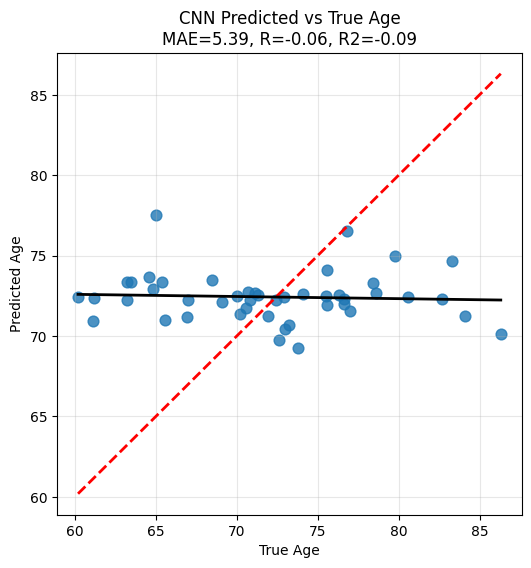

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

DATA_DIR = "/content/drive/MyDrive/fmri_project/outputs"   # change if needed
pred_path = os.path.join(DATA_DIR, "cnn_hemi_predictions.csv")

df = pd.read_csv(pred_path)
print(df.head())

# If each subject appears once overall, this is enough.
# If a subject can appear multiple times, average predictions per subject:
plot_df = df.groupby("subject", as_index=False).agg(
    true_age=("true_age", "mean"),
    pred_age=("pred_age", "mean"),
    brain_age_gap=("brain_age_gap", "mean")
)

y_true = plot_df["true_age"].values
y_pred = plot_df["pred_age"].values

mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
r = np.corrcoef(y_true, y_pred)[0, 1]

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, s=60, alpha=0.8)
mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], "r--", linewidth=2)

# optional best-fit line
coef = np.polyfit(y_true, y_pred, 1)
xline = np.linspace(mn, mx, 100)
yline = coef[0] * xline + coef[1]
plt.plot(xline, yline, color="black", linewidth=2)

plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title(f"CNN Predicted vs True Age\nMAE={mae:.2f}, R={r:.2f}, R2={r2:.2f}")
plt.grid(alpha=0.3)
plt.show()


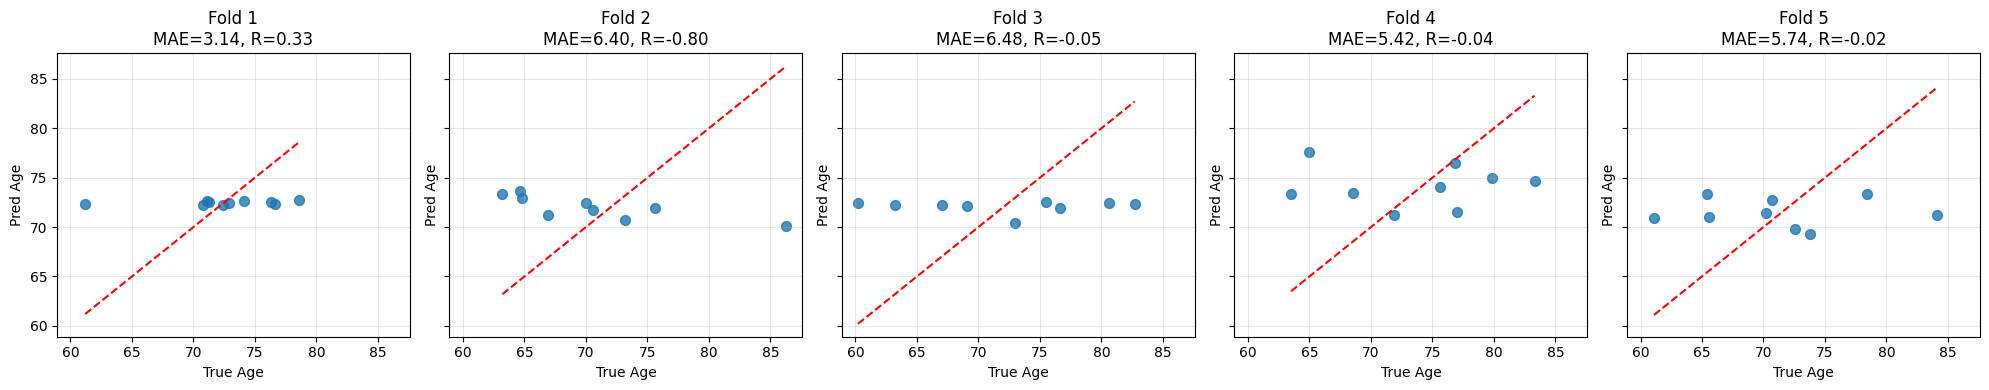

In [ ]:
folds = sorted(df["fold"].unique())

fig, axes = plt.subplots(1, len(folds), figsize=(4*len(folds), 4), sharex=True, sharey=True)
if len(folds) == 1:
    axes = [axes]

for ax, fold in zip(axes, folds):
    sub = df[df["fold"] == fold]
    y_true = sub["true_age"].values
    y_pred = sub["pred_age"].values
    r = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    mae = mean_absolute_error(y_true, y_pred)

    ax.scatter(y_true, y_pred, s=50, alpha=0.8)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.5)
    ax.set_title(f"Fold {fold}\nMAE={mae:.2f}, R={r:.2f}")
    ax.set_xlabel("True Age")
    ax.set_ylabel("Pred Age")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# GNN


In [ ]:
# ============================================================
# Stable GNN baseline for brain age prediction
# Comparative analysis model using FULL connectivity
# Loads from fmri_features.npz
# ============================================================

# If needed in Colab:
# !pip install -q torch-geometric

from google.colab import drive
drive.mount('/content/drive')

import os
import copy
import math
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

# --------------------------------------------------
# 1. Config
# --------------------------------------------------
DATA_DIR = "/content/drive/MyDrive/fmri_project/outputs"
NPZ_FILE = "fmri_features.npz"

SEED = 42
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 100
PATIENCE = 12
TOP_K = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# --------------------------------------------------
# 2. Load data
# --------------------------------------------------
fmri_data = np.load(os.path.join(DATA_DIR, NPZ_FILE), allow_pickle=True)

ages = fmri_data["ages"].astype(np.float32)
full_vec = fmri_data["FULL"].astype(np.float32)
subjects = fmri_data["subjects"]

print("ages:", ages.shape)
print("FULL:", full_vec.shape)
print("subjects:", subjects.shape)

assert len(ages) == len(full_vec) == len(subjects)

# --------------------------------------------------
# 3. Helpers
# --------------------------------------------------
def infer_n_from_upper_triangle_length(m):
    n = int((1 + np.sqrt(1 + 8 * m)) / 2)
    if n * (n - 1) // 2 != m:
        raise ValueError(f"Cannot infer square size from upper-triangle length {m}")
    return n

def vec_to_sym_matrix(batch_vec, n):
    N = batch_vec.shape[0]
    mat = np.zeros((N, n, n), dtype=np.float32)
    iu = np.triu_indices(n, k=1)
    mat[:, iu[0], iu[1]] = batch_vec
    mat[:, iu[1], iu[0]] = batch_vec
    return mat

def fisher_z(x, eps=1e-4):
    x = np.asarray(x, dtype=np.float32)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = np.clip(x, -1 + eps, 1 - eps)
    z = np.arctanh(x)
    z = np.nan_to_num(z, nan=0.0, posinf=0.0, neginf=0.0)
    return z

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    r = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "r": r}

# --------------------------------------------------
# 4. Reconstruct FULL matrix
# --------------------------------------------------
n_nodes = infer_n_from_upper_triangle_length(full_vec.shape[1])
full_mat = vec_to_sym_matrix(full_vec, n_nodes)

for i in range(full_mat.shape[0]):
    np.fill_diagonal(full_mat[i], 0.0)

full_mat = fisher_z(full_mat)
full_mat = np.nan_to_num(full_mat, nan=0.0, posinf=0.0, neginf=0.0)

print("FULL matrix:", full_mat.shape)
print("Any NaN in full_mat?", np.isnan(full_mat).any())
print("Any Inf in full_mat?", np.isinf(full_mat).any())

# --------------------------------------------------
# 5. Build one graph per subject
# Unweighted top-k graph for stability
# Node features = local connectivity summaries
# --------------------------------------------------
def build_subject_graph(fc_matrix, age, subject_id, top_k=10):
    A = np.array(fc_matrix, dtype=np.float32, copy=True)
    A = np.nan_to_num(A, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(A, 0.0)

    absA = np.abs(A)
    absA = np.nan_to_num(absA, nan=0.0, posinf=0.0, neginf=0.0)

    node_strength = absA.sum(axis=1, keepdims=True)
    node_mean = absA.mean(axis=1, keepdims=True)
    node_std = absA.std(axis=1, keepdims=True)
    x = np.concatenate([node_strength, node_mean, node_std], axis=1).astype(np.float32)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    edge_pairs = set()

    for i in range(A.shape[0]):
        nbrs = np.argsort(absA[i])[-top_k:]
        for j in nbrs:
            if i == j:
                continue
            edge_pairs.add((i, j))
            edge_pairs.add((j, i))

    edge_index = torch.tensor(list(edge_pairs), dtype=torch.long).t().contiguous()

    data = Data(
        x=torch.tensor(x, dtype=torch.float32),
        edge_index=edge_index,
        y=torch.tensor([age], dtype=torch.float32)
    )
    data.subject = subject_id
    return data

graphs = [
    build_subject_graph(full_mat[i], ages[i], subjects[i], top_k=TOP_K)
    for i in range(len(ages))
]

print("Number of graphs:", len(graphs))
print("Example graph:", graphs[0])

for k, g in enumerate(graphs):
    if torch.isnan(g.x).any() or torch.isnan(g.y).any():
        print("NaN found in graph", k, g.subject)
        break
else:
    print("No NaNs found in graphs")

# --------------------------------------------------
# 6. Small GCN regressor
# --------------------------------------------------
class BrainAgeGCN(nn.Module):
    def __init__(self, in_channels=3, hidden=32):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, hidden)

        self.head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(32, 1)
        )

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.25, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)
        x = self.head(x)
        return x

# --------------------------------------------------
# 7. Train / eval
# --------------------------------------------------
def run_epoch(model, loader, criterion, optimizer=None, y_mean=None, y_std=None):
    train = optimizer is not None
    model.train() if train else model.eval()

    losses = []
    preds_all, targets_all = [], []

    for batch in loader:
        batch = batch.to(device)
        y_true = batch.y.view(-1, 1)
        y_std_target = (y_true - y_mean) / y_std

        with torch.set_grad_enabled(train):
            pred_std = model(batch.x, batch.edge_index, batch.batch)

            if torch.isnan(pred_std).any() or torch.isinf(pred_std).any():
                raise ValueError("Model produced NaN/Inf outputs")

            loss = criterion(pred_std, y_std_target)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        pred = pred_std * y_std + y_mean

        losses.append(loss.item())
        preds_all.append(pred.detach().cpu().numpy())
        targets_all.append(y_true.detach().cpu().numpy())

    preds_all = np.concatenate(preds_all).reshape(-1)
    targets_all = np.concatenate(targets_all).reshape(-1)

    preds_all = np.nan_to_num(preds_all, nan=0.0, posinf=0.0, neginf=0.0)
    targets_all = np.nan_to_num(targets_all, nan=0.0, posinf=0.0, neginf=0.0)

    metrics = regression_metrics(targets_all, preds_all)
    metrics["loss"] = float(np.mean(losses))
    return metrics, targets_all, preds_all

# --------------------------------------------------
# 8. Grouped 5-fold CV
# --------------------------------------------------
gkf = GroupKFold(n_splits=5)
fold_results = []
pred_rows = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(np.arange(len(graphs)), ages, groups=subjects), start=1):
    print(f"\n===== Fold {fold} =====")

    train_subjects = subjects[train_idx]
    unique_subs = np.unique(train_subjects)
    rng = np.random.RandomState(SEED + fold)
    rng.shuffle(unique_subs)

    val_count = max(1, int(0.2 * len(unique_subs)))
    val_subs = set(unique_subs[:val_count])

    val_mask = np.array([s in val_subs for s in train_subjects])
    inner_train_idx = train_idx[~val_mask]
    val_idx = train_idx[val_mask]

    train_graphs = [graphs[i] for i in inner_train_idx]
    val_graphs = [graphs[i] for i in val_idx]
    test_graphs = [graphs[i] for i in test_idx]

    y_mean = torch.tensor(ages[inner_train_idx].mean(), dtype=torch.float32, device=device).view(1, 1)
    y_std = torch.tensor(ages[inner_train_idx].std() + 1e-6, dtype=torch.float32, device=device).view(1, 1)

    train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

    model = BrainAgeGCN(in_channels=3, hidden=32).to(device)
    criterion = nn.HuberLoss(delta=1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5
    )

    best_state = None
    best_val_mae = float("inf")
    wait = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_metrics, _, _ = run_epoch(model, train_loader, criterion, optimizer, y_mean, y_std)
        val_metrics, _, _ = run_epoch(model, val_loader, criterion, None, y_mean, y_std)

        scheduler.step(val_metrics["MAE"])

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"Fold {fold} Epoch {epoch:03d} | "
                f"Train MAE {train_metrics['MAE']:.3f} | "
                f"Val MAE {val_metrics['MAE']:.3f}"
            )

        if val_metrics["MAE"] < best_val_mae:
            best_val_mae = val_metrics["MAE"]
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print("Early stopping")
                break

    model.load_state_dict(best_state)
    test_metrics, test_true, test_pred = run_epoch(model, test_loader, criterion, None, y_mean, y_std)

    print("Fold test metrics:", test_metrics)
    fold_results.append(test_metrics)

    for local_i, subj_i in enumerate(test_idx):
        pred_rows.append({
            "fold": fold,
            "subject": subjects[subj_i],
            "true_age": float(test_true[local_i]),
            "pred_age": float(test_pred[local_i]),
            "brain_age_gap": float(test_pred[local_i] - test_true[local_i])
        })

# --------------------------------------------------
# 9. Save results
# --------------------------------------------------
results_df = pd.DataFrame(fold_results)
preds_df = pd.DataFrame(pred_rows)

print("\n===== 5-Fold CV Summary =====")
print(results_df)
print("\nMean metrics:")
print(results_df.mean(numeric_only=True))
print("\nStd metrics:")
print(results_df.std(numeric_only=True))

results_df.to_csv(os.path.join(DATA_DIR, "gnn_results.csv"), index=False)
preds_df.to_csv(os.path.join(DATA_DIR, "gnn_predictions.csv"), index=False)

print("\nSaved:")
print(os.path.join(DATA_DIR, "gnn_results.csv"))
print(os.path.join(DATA_DIR, "gnn_predictions.csv"))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu
ages: (46,)
FULL: (46, 7140)
subjects: (46,)
FULL matrix: (46, 120, 120)
Any NaN in full_mat? False
Any Inf in full_mat? False
Number of graphs: 46
Example graph: Data(x=[120, 3], edge_index=[2, 1580], y=[1], subject='sub-002S1261')
No NaNs found in graphs

===== Fold 1 =====
Fold 1 Epoch 001 | Train MAE 5.562 | Val MAE 7.342
Fold 1 Epoch 010 | Train MAE 5.871 | Val MAE 7.114
Early stopping
Fold test metrics: {'MAE': 3.4953792095184326, 'RMSE': 4.764436967695199, 'R2': -0.10644149780273438, 'r': np.float64(0.05296950849472735), 'loss': 0.3443629592657089}

===== Fold 2 =====
Fold 2 Epoch 001 | Train MAE 5.397 | Val MAE 5.713
Fold 2 Epoch 010 | Train MAE 5.004 | Val MAE 5.523
Fold 2 Epoch 020 | Train MAE 5.141 | Val MAE 5.503
Early stopping
Fold test metrics: {'MAE': 5.787969589233398, 'RMSE': 7.100169768117096, 'R2': -0.08883249759674072, 'r': np.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

OUT_DIR = "/content/drive/MyDrive/fmri_project/outputs"  # change if needed

results_df = pd.read_csv(os.path.join(OUT_DIR, "gnn_results.csv"))
preds_df = pd.read_csv(os.path.join(OUT_DIR, "gnn_predictions.csv"))

print(results_df)
print(preds_df.head())


        MAE      RMSE        R2         r      loss
0  3.495379  4.764437 -0.106441  0.052970  0.344363
1  5.787970  7.100170 -0.088832  0.112916  0.483137
2  6.688827  7.440655 -0.053539 -0.081601  0.457824
3  5.697093  6.484222 -0.042186  0.475581  0.608494
4  5.301261  6.646330 -0.006246 -0.273928  0.495540
   fold       subject   true_age   pred_age  brain_age_gap
0     1  sub-002S1261  71.099998  71.179718       0.079720
1     1  sub-007S4637  70.800003  70.953461       0.153458
2     1  sub-021S6910  76.599998  71.080948      -5.519051
3     1  sub-035S0156  74.099998  71.056305      -3.043694
4     1  sub-041S4427  71.300003  71.152580      -0.147423


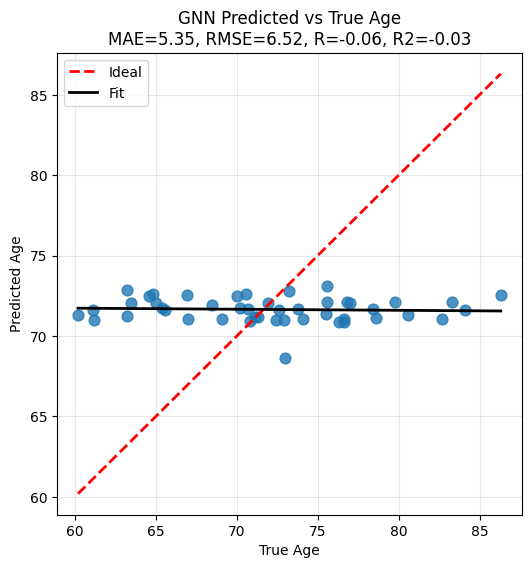

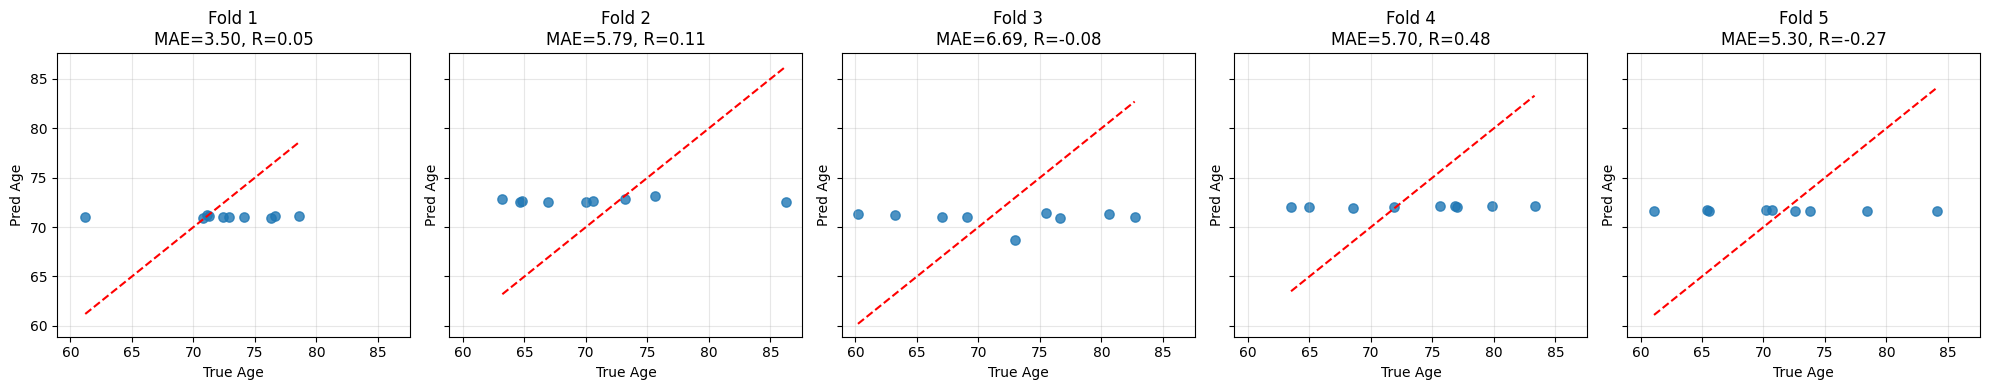

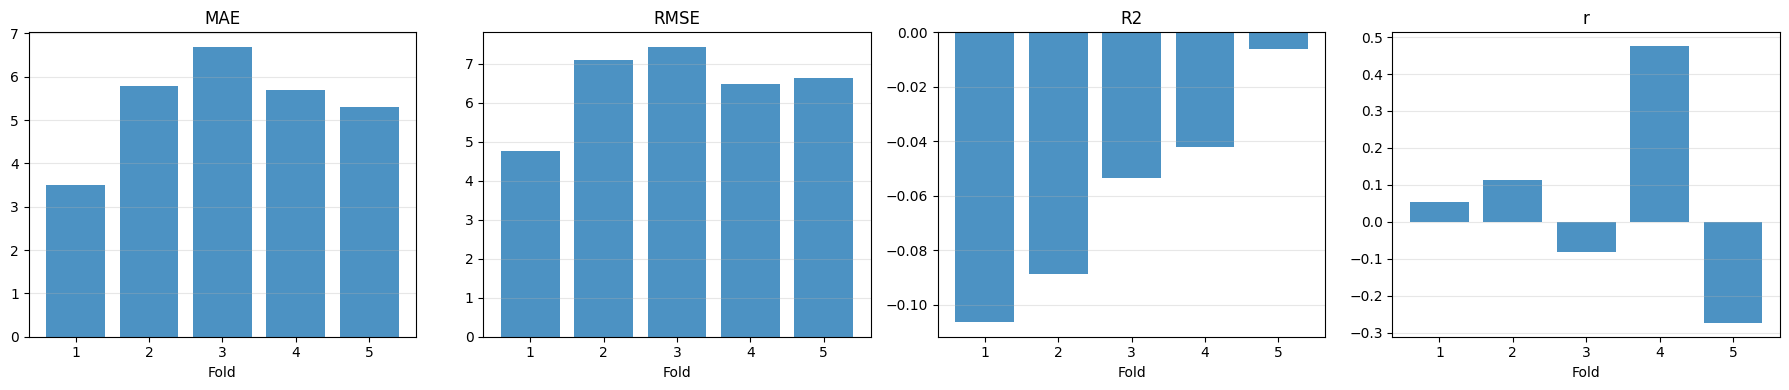

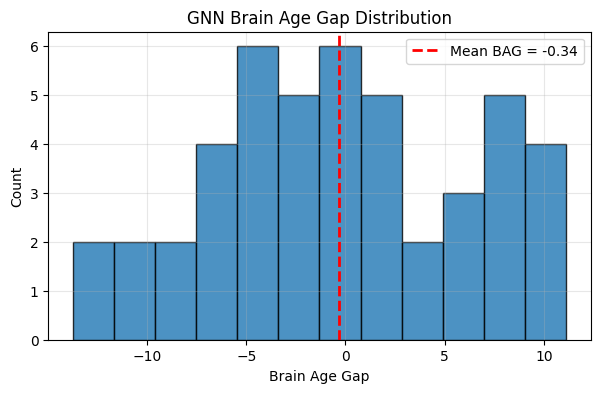

In [ ]:
plot_df = preds_df.groupby("subject", as_index=False).agg(
    true_age=("true_age", "mean"),
    pred_age=("pred_age", "mean"),
    brain_age_gap=("brain_age_gap", "mean")
)

y_true = plot_df["true_age"].values
y_pred = plot_df["pred_age"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = math.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
r = np.corrcoef(y_true, y_pred)[0, 1]

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, s=60, alpha=0.8)

mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], "r--", linewidth=2, label="Ideal")

coef = np.polyfit(y_true, y_pred, 1)
xline = np.linspace(mn, mx, 100)
yline = coef[0] * xline + coef[1]
plt.plot(xline, yline, "k-", linewidth=2, label="Fit")

plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title(f"GNN Predicted vs True Age\nMAE={mae:.2f}, RMSE={rmse:.2f}, R={r:.2f}, R2={r2:.2f}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Fold-wise predicted vs true:

folds = sorted(preds_df["fold"].unique())

fig, axes = plt.subplots(1, len(folds), figsize=(4*len(folds), 4), sharex=True, sharey=True)
if len(folds) == 1:
    axes = [axes]

for ax, fold in zip(axes, folds):
    sub = preds_df[preds_df["fold"] == fold]
    y_true = sub["true_age"].values
    y_pred = sub["pred_age"].values

    mae = mean_absolute_error(y_true, y_pred)
    r = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan

    ax.scatter(y_true, y_pred, s=45, alpha=0.8)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.5)

    ax.set_title(f"Fold {fold}\nMAE={mae:.2f}, R={r:.2f}")
    ax.set_xlabel("True Age")
    ax.set_ylabel("Pred Age")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Bar plot of fold metrics:

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

metrics = ["MAE", "RMSE", "R2", "r"]
for ax, metric in zip(axes, metrics):
    ax.bar(results_df.index + 1, results_df[metric], alpha=0.8)
    ax.set_title(metric)
    ax.set_xlabel("Fold")
    ax.set_xticks(results_df.index + 1)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Brain age gap distribution:

plt.figure(figsize=(7, 4))
plt.hist(preds_df["brain_age_gap"], bins=12, edgecolor="black", alpha=0.8)
plt.axvline(preds_df["brain_age_gap"].mean(), color="red", linestyle="--", linewidth=2,
            label=f"Mean BAG = {preds_df['brain_age_gap'].mean():.2f}")
plt.xlabel("Brain Age Gap")
plt.ylabel("Count")
plt.title("GNN Brain Age Gap Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# SVR & SVM

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------
# 1. Config
# --------------------------------------------------
DATA_DIR = "/content/drive/MyDrive/fmri_project/outputs"
NPZ_FILE = "fmri_features.npz"
OUT_DIR = "/content/drive/MyDrive/fmri_project/outputs"

os.makedirs(OUT_DIR, exist_ok=True)

# --------------------------------------------------
# 2. Load data
# --------------------------------------------------
fmri_data = np.load(os.path.join(DATA_DIR, NPZ_FILE), allow_pickle=True)

ages = fmri_data["ages"].astype(np.float32)
full_vec = fmri_data["FULL"].astype(np.float32)
ll_vec = fmri_data["LL"].astype(np.float32)
lr_vec = fmri_data["LR"].astype(np.float32)
rr_vec = fmri_data["RR"].astype(np.float32)
subjects = fmri_data["subjects"]

print("ages:", ages.shape)
print("FULL:", full_vec.shape)
print("LL:", ll_vec.shape)
print("LR:", lr_vec.shape)
print("RR:", rr_vec.shape)
print("subjects:", subjects.shape)

assert len(ages) == len(full_vec) == len(ll_vec) == len(lr_vec) == len(rr_vec) == len(subjects)

# --------------------------------------------------
# 3. Feature sets
# --------------------------------------------------
X_full = full_vec
X_hemi = np.concatenate([ll_vec, lr_vec, rr_vec], axis=1)
X_all = np.concatenate([full_vec, ll_vec, lr_vec, rr_vec], axis=1)
y = ages

feature_sets = {
    "FULL_only": X_full,
    "HEMI_only": X_hemi,
    "FULL_plus_HEMI": X_all,
}

# --------------------------------------------------
# 4. Metrics
# --------------------------------------------------
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    r = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "r": r}

# --------------------------------------------------
# 5. Outer CV
# --------------------------------------------------
outer_cv = GroupKFold(n_splits=5)

all_results = []
all_preds = []

for feature_name, X in feature_sets.items():
    print(f"\n========== {feature_name} ==========")

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups=subjects), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        g_train = subjects[train_idx]

        # Inner tuning
        inner_cv = GroupKFold(n_splits=3)

        max_pca = min(X_train.shape[0] - 1, X_train.shape[1])
        pca_grid = [5, 10, 15, 20]
        pca_grid = [n for n in pca_grid if n <= max_pca]
        if len(pca_grid) == 0:
            pca_grid = [min(5, max_pca)]

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA()),
            ("svr", SVR(kernel="rbf"))
        ])

        param_grid = {
            "pca__n_components": pca_grid,
            "svr__C": [0.1, 1, 10, 100],
            "svr__gamma": ["scale", 0.01, 0.1, 1.0],
            "svr__epsilon": [0.1, 1.0, 2.0],
        }

        search = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring="neg_mean_absolute_error",
            cv=inner_cv,
            n_jobs=-1,
            refit=True
        )

        search.fit(X_train, y_train, groups=g_train)
        best_model = search.best_estimator_
        y_pred = best_model.predict(X_test)

        metrics = regression_metrics(y_test, y_pred)

        print(
            f"Fold {fold} | "
            f"Inner best MAE = {-search.best_score_:.3f} | "
            f"Test MAE = {metrics['MAE']:.3f} | "
            f"R = {metrics['r']:.3f} | "
            f"R2 = {metrics['R2']:.3f}"
        )

        all_results.append({
            "feature_set": feature_name,
            "fold": fold,
            "best_params": str(search.best_params_),
            **metrics
        })

        for s, yt, yp in zip(subjects[test_idx], y_test, y_pred):
            all_preds.append({
                "feature_set": feature_name,
                "fold": fold,
                "subject": s,
                "true_age": float(yt),
                "pred_age": float(yp),
                "brain_age_gap": float(yp - yt)
            })

# --------------------------------------------------
# 6. Save results
# --------------------------------------------------
results_df = pd.DataFrame(all_results)
preds_df = pd.DataFrame(all_preds)

results_path = os.path.join(OUT_DIR, "svr_results.csv")
preds_path = os.path.join(OUT_DIR, "svr_predictions.csv")

results_df.to_csv(results_path, index=False)
preds_df.to_csv(preds_path, index=False)

print("\nSaved:")
print(results_path)
print(preds_path)

print("\nPer-fold results:")
print(results_df)

summary_df = results_df.groupby("feature_set")[["MAE", "RMSE", "R2", "r"]].agg(["mean", "std"])
print("\nSummary by feature set:")
print(summary_df)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ages: (46,)
FULL: (46, 7140)
LL: (46, 1540)
LR: (46, 3136)
RR: (46, 1540)
subjects: (46,)

========== FULL_only ==========
Fold 1 | Inner best MAE = 5.980 | Test MAE = 3.257 | R = 0.422 | R2 = -0.015
Fold 2 | Inner best MAE = 4.880 | Test MAE = 6.584 | R = -0.220 | R2 = -0.289
Fold 3 | Inner best MAE = 4.774 | Test MAE = 7.042 | R = -0.148 | R2 = -0.105
Fold 4 | Inner best MAE = 5.181 | Test MAE = 5.863 | R = -0.126 | R2 = -0.101
Fold 5 | Inner best MAE = 5.263 | Test MAE = 4.537 | R = 0.626 | R2 = 0.275

========== HEMI_only ==========
Fold 1 | Inner best MAE = 5.979 | Test MAE = 3.118 | R = 0.266 | R2 = 0.012
Fold 2 | Inner best MAE = 4.850 | Test MAE = 6.670 | R = 0.085 | R2 = -0.292
Fold 3 | Inner best MAE = 4.804 | Test MAE = 6.661 | R = -0.175 | R2 = -0.134
Fold 4 | Inner best MAE = 5.171 | Test MAE = 5.827 | R = 0.156 | R2 = -0.095
Fold 5 | Inner best 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

preds_df = pd.read_csv("/content/drive/MyDrive/fmri_project/outputs/svr_predictions.csv")
results_df = pd.read_csv("/content/drive/MyDrive/fmri_project/outputs/svr_results.csv")

best_feature = (
    results_df.groupby("feature_set")["MAE"]
    .mean()
    .sort_values()
    .index[0]
)

print("Best feature set:", best_feature)

plot_df = preds_df[preds_df["feature_set"] == best_feature].groupby("subject", as_index=False).agg(
    true_age=("true_age", "mean"),
    pred_age=("pred_age", "mean"),
    brain_age_gap=("brain_age_gap", "mean")
)

y_true = plot_df["true_age"].values
y_pred = plot_df["pred_age"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = math.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
r = np.corrcoef(y_true, y_pred)[0, 1]

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, s=60, alpha=0.8)

mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], "r--", linewidth=2, label="Ideal")

coef = np.polyfit(y_true, y_pred, 1)
xline = np.linspace(mn, mx, 100)
yline = coef[0] * xline + coef[1]
plt.plot(xline, yline, "k-", linewidth=2, label="Fit")

plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title(f"SVR Predicted vs True Age\n{best_feature}\nMAE={mae:.2f}, RMSE={rmse:.2f}, R={r:.2f}, R2={r2:.2f}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# SVM (ll, rr, lr)

# SVM (my code)